## Caso de Estudio: Análisis de Rendimiento de Ventas Regionales para Optimización Estratégica
### Descripción del Caso:

Una cadena de ventas global desea analizar su rendimiento de ventas a lo largo del tiempo, por regiones y productos. La gerencia busca obtener información accionable para:
- Detectar productos de alto y bajo rendimiento.
- Identificar regiones con bajo desempeño.
- Analizar el comportamiento de ventas en festividades y estaciones.
- Estimar el impacto de promociones.

## Base de Datos de Referencia:
Se utilizará el esquema de ejemplo SH (Sales History) de Oracle, que contiene tablas como:
- CUSTOMERS
- SALES
- PRODUCTS
- CHANNELS
- TIMES
- PROMOTIONS

## Objetivos de BI:
Top 5 productos más vendidos por región.
- Comparación de ventas año a año.
- Análisis de impacto de promociones en las ventas.
- Canal de venta con mayor crecimiento.
- Segmentación de clientes por volumen de compra.

## ¿Cómo instalar el esquema SH en Oracle?
En igual manera que se instalo el esquema HR, (es decir crea un nuevo usuario llamado SH) y descarga del siguiente link: 
- 🔗 Descarga desde Oracle GitHub:
- https://github.com/oracle/db-sample-schemas

## Pasos de instalac ion del esquema SH:
- Clona el repositorio o descarga el ZIP.
- Entra en la carpeta sales_history (/sh/).
- Sigue las instrucciones del README.md para instalar el esquema SH.
- Recuerda tener permisos de DBA para instalar el esquema en Oracle.

In [1]:
# ======================================
# 1. Configuración Inicial
# ======================================

# Instalación de paquetes necesarios 
import oracledb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
# ======================================
# 2. Conexión a la Base de Datos Oracle
# ======================================

# Reemplazar con tus credenciales y datos de conexión
import oracledb 

try:
    conn = oracledb.connect(
        user="sh",
        password="basededatos",
        dsn="localhost:1521/xe"  
    )

except oracledb.Error as e:
    print(f" Ocurrió un error de base de datos: {e}")

In [ ]:
# ======================================
# CONFIGURACIÓN + CONEXIÓN + FUNCIÓN
# ======================================

# IMPORTS
import oracledb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

connection = oracledb.connect(
    user="sh",
    password="basededatos",
    dsn="localhost:1521/xe"
)


def run_query(query):
    df = pd.read_sql(query, con=connection)
    return df

print("Función run_query OK")



df_test = run_query("SELECT COUNT(*) AS TOTAL FROM sh.sales")
print(df_test)


Imports OK
Conexión Oracle OK
Función run_query OK
    TOTAL
0  918843


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


## ======================================
## 4. Análisis de BI (Consultas SQL y visualizaciones)
## ======================================


In [ ]:
# -----------------------------
# 4.1 Top 5 productos más vendidos por país
# -----------------------------

import oracledb
import matplotlib.pyplot as plt
import pandas as pd

try:
    conn = oracledb.connect(
        user='sh',
        password='basededatos',
        dsn='localhost:1521/XE'
    )
except oracledb.Error as e:
    print(e)

cursor = conn.cursor()
cursor.execute(
"""

"""
)


# query = """
# SELECT
#     co.country_name    AS COUNTRY,
#     p.prod_name        AS PRODUCT,
#     SUM(s.amount_sold) AS TOTAL_SALES
# FROM sh.sales s
# JOIN sh.customers cu ON s.cust_id = cu.cust_id
# JOIN sh.countries co ON cu.country_id = co.country_id
# JOIN sh.products p   ON s.prod_id = p.prod_id
# GROUP BY co.country_name, p.prod_name
# """

# df_pais_producto = run_query(query)


# df_pais_producto['TOTAL_SALES'] = pd.to_numeric(
#     df_pais_producto['TOTAL_SALES'],
#     errors='coerce'
# )


# df_pais_producto = df_pais_producto.dropna()


# df_top5 = (
#     df_pais_producto
#     .sort_values(['COUNTRY', 'TOTAL_SALES'], ascending=[True, False])
#     .groupby('COUNTRY')
#     .head(5)
# )

# # Mostrar tabla
# df_top5


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


,COUNTRY,PRODUCT,TOTAL_SALES
28,Argentina,Speed Trainer Bats and Training Program,5399.94
31,Argentina,English Willow Cricket Bat,1352.93
30,Argentina,Pro Style Batting Tee,910.32
360,Argentina,5 Point Batting Tee,787.46
242,Argentina,Team shirt,726.33
...,...,...,...
540,United States of America,Lithium Electric Golf Caddy,7553716.46
221,United States of America,Soccer Goal - Official,4105733.50
102,United States of America,Pitching Machine and Batting Cage Combo,3651721.07
896,United States of America,Match Used Autograph Racquet,3405357.55


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


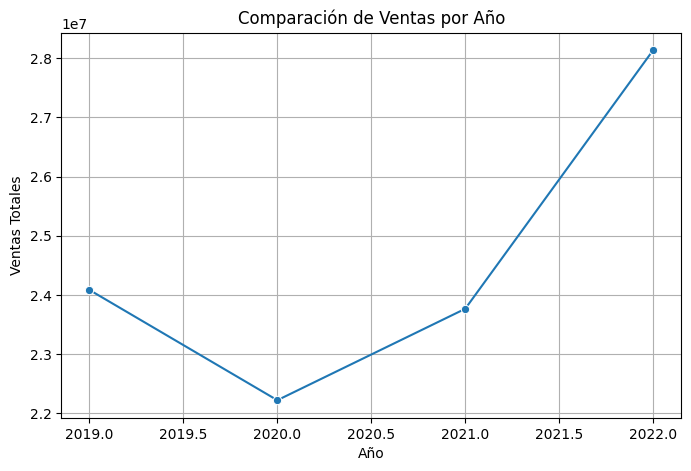

In [5]:
# -----------------------------
# 4.2 Comparación de ventas por año
# -----------------------------

query = """
SELECT
    t.calendar_year AS YEAR,
    SUM(s.amount_sold) AS TOTAL_SALES
FROM sh.sales s
JOIN sh.times t ON s.time_id = t.time_id
GROUP BY t.calendar_year
ORDER BY t.calendar_year
"""


df_ventas_anio = run_query(query)


df_ventas_anio

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df_ventas_anio,
    x='YEAR',
    y='TOTAL_SALES',
    marker='o'
)
plt.title("Comparación de Ventas por Año")
plt.xlabel("Año")
plt.ylabel("Ventas Totales")
plt.grid(True)
plt.show()



C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


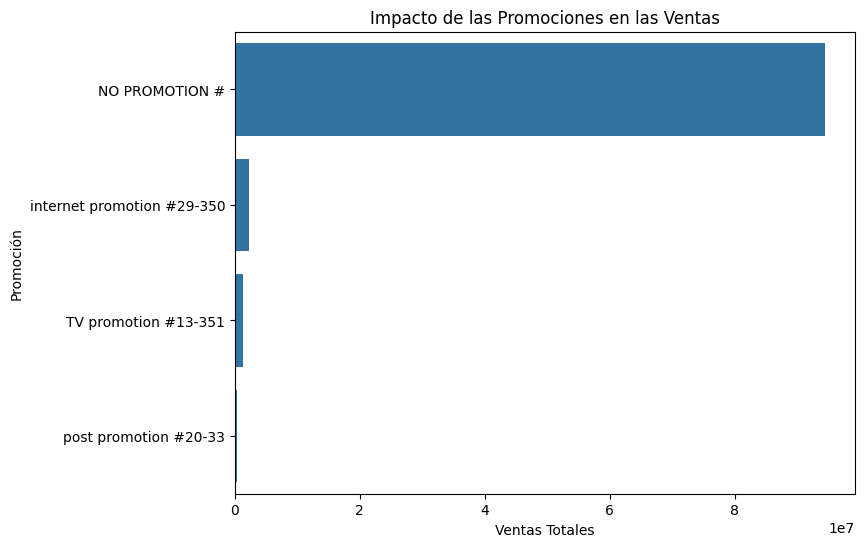

In [6]:
# -----------------------------
# 4.3 Impacto de promociones en las ventas
# -----------------------------

query = """
SELECT
    p.promo_name AS PROMOTION,
    SUM(s.amount_sold) AS TOTAL_SALES
FROM sh.sales s
JOIN sh.promotions p ON s.promo_id = p.promo_id
GROUP BY p.promo_name
ORDER BY TOTAL_SALES DESC
"""


df_promociones = run_query(query)


df_promociones

plt.figure(figsize=(8,6))
sns.barplot(
    data=df_promociones,
    x='TOTAL_SALES',
    y='PROMOTION'
)
plt.title("Impacto de las Promociones en las Ventas")
plt.xlabel("Ventas Totales")
plt.ylabel("Promoción")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


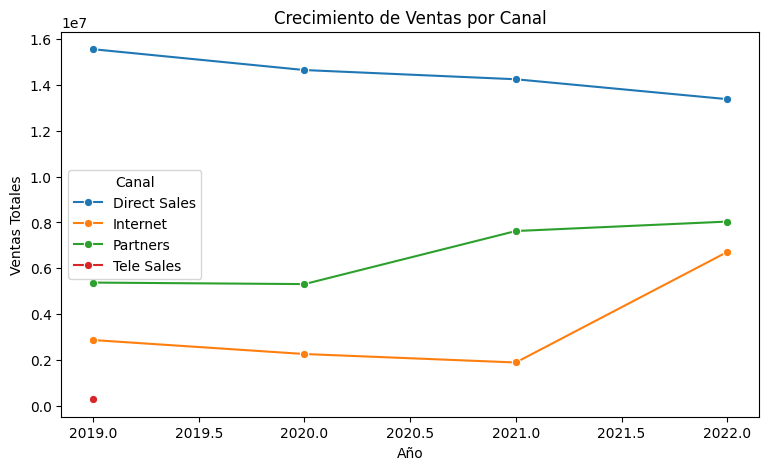

In [7]:
# -----------------------------
# 4.4 Canal de venta con mayor crecimiento
# -----------------------------

query = """
SELECT
    ch.channel_desc AS CHANNEL,
    t.calendar_year AS YEAR,
    SUM(s.amount_sold) AS TOTAL_SALES
FROM sh.sales s
JOIN sh.channels ch ON s.channel_id = ch.channel_id
JOIN sh.times t ON s.time_id = t.time_id
GROUP BY ch.channel_desc, t.calendar_year
ORDER BY ch.channel_desc, t.calendar_year
"""


df_canal = run_query(query)


df_canal


plt.figure(figsize=(9,5))
sns.lineplot(
    data=df_canal,
    x='YEAR',
    y='TOTAL_SALES',
    hue='CHANNEL',
    marker='o'
)
plt.title("Crecimiento de Ventas por Canal")
plt.xlabel("Año")
plt.ylabel("Ventas Totales")
plt.legend(title="Canal")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


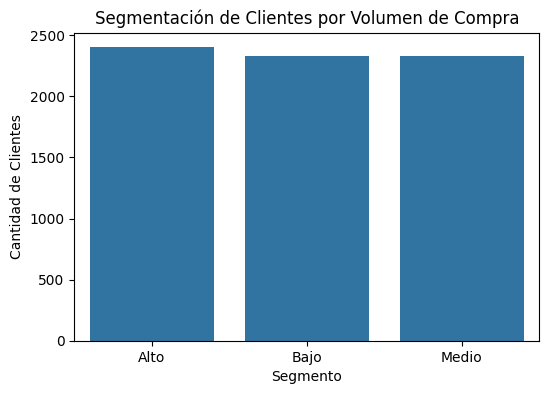

In [8]:
# -----------------------------
# 4.5 Segmentación de clientes por volumen de compra (VERSIÓN DEFINITIVA)
# -----------------------------

query = """
SELECT
    c.cust_id AS CUSTOMER_ID,
    c.cust_city AS CITY,
    SUM(s.amount_sold) AS TOTAL_PURCHASE
FROM sh.sales s
JOIN sh.customers c ON s.cust_id = c.cust_id
GROUP BY c.cust_id, c.cust_city
"""


df_clientes = run_query(query)


df_clientes = df_clientes.dropna(subset=['TOTAL_PURCHASE'])
df_clientes = df_clientes[df_clientes['TOTAL_PURCHASE'] > 0]

df_clientes['RANK'] = df_clientes['TOTAL_PURCHASE'].rank(method='first')


n = len(df_clientes)
bajo = n * 0.33
medio = n * 0.66


def segmentar(rank):
    if rank <= bajo:
        return 'Bajo'
    elif rank <= medio:
        return 'Medio'
    else:
        return 'Alto'

df_clientes['SEGMENT'] = df_clientes['RANK'].apply(segmentar)


df_segmentos = df_clientes['SEGMENT'].value_counts().reset_index()
df_segmentos.columns = ['SEGMENT', 'CUSTOMER_COUNT']


df_segmentos


plt.figure(figsize=(6,4))
sns.barplot(
    data=df_segmentos,
    x='SEGMENT',
    y='CUSTOMER_COUNT'
)
plt.title("Segmentación de Clientes por Volumen de Compra")
plt.xlabel("Segmento")
plt.ylabel("Cantidad de Clientes")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


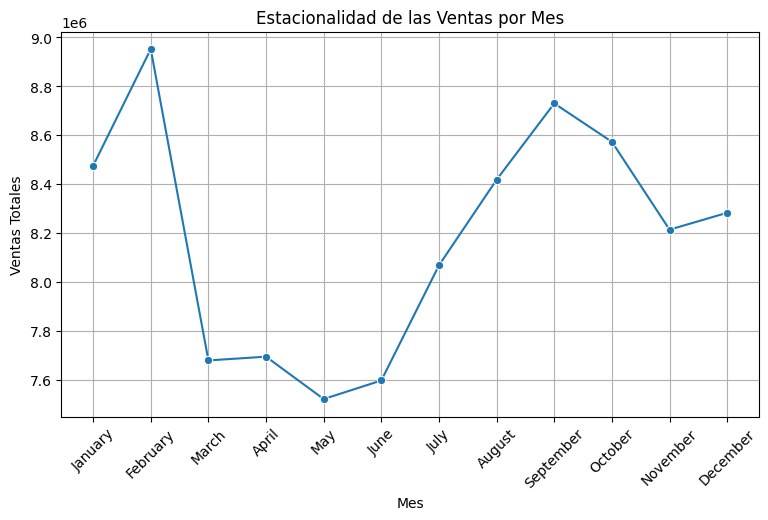

In [9]:
# -----------------------------
# 4.6 Identificación de estacionalidad en las ventas (CORREGIDA)
# -----------------------------

query = """
SELECT
    t.calendar_month_number AS MONTH_NUM,
    t.calendar_month_name   AS MONTH_NAME,
    SUM(s.amount_sold)      AS TOTAL_SALES
FROM sh.sales s
JOIN sh.times t ON s.time_id = t.time_id
GROUP BY t.calendar_month_number, t.calendar_month_name
ORDER BY t.calendar_month_number
"""


df_estacionalidad = run_query(query)


df_estacionalidad['TOTAL_SALES'] = pd.to_numeric(
    df_estacionalidad['TOTAL_SALES'],
    errors='coerce'
)


df_estacionalidad = df_estacionalidad.dropna(subset=['TOTAL_SALES'])


df_estacionalidad


plt.figure(figsize=(9,5))
sns.lineplot(
    data=df_estacionalidad,
    x='MONTH_NUM',
    y='TOTAL_SALES',
    marker='o'
)
plt.xticks(
    df_estacionalidad['MONTH_NUM'],
    df_estacionalidad['MONTH_NAME'],
    rotation=45
)
plt.title("Estacionalidad de las Ventas por Mes")
plt.xlabel("Mes")
plt.ylabel("Ventas Totales")
plt.grid(True)
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


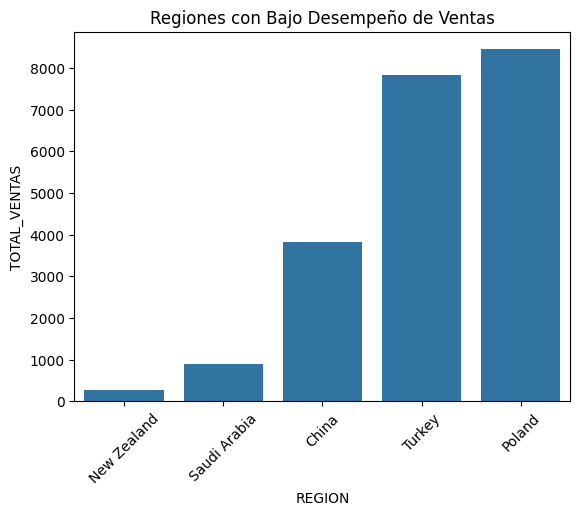

In [10]:
# ======================================
# 4.7 REGIONES CON BAJO DESEMPEÑO
# ======================================
query_47 = """
SELECT
    co.country_name AS REGION,
    SUM(s.amount_sold) AS TOTAL_VENTAS
FROM sales s
JOIN customers c ON s.cust_id = c.cust_id
JOIN countries co ON c.country_id = co.country_id
GROUP BY co.country_name
ORDER BY TOTAL_VENTAS ASC
"""

df_47 = run_query(query_47)

sns.barplot(data=df_47.head(5), x='REGION', y='TOTAL_VENTAS')
plt.title("Regiones con Bajo Desempeño de Ventas")
plt.xticks(rotation=45)
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


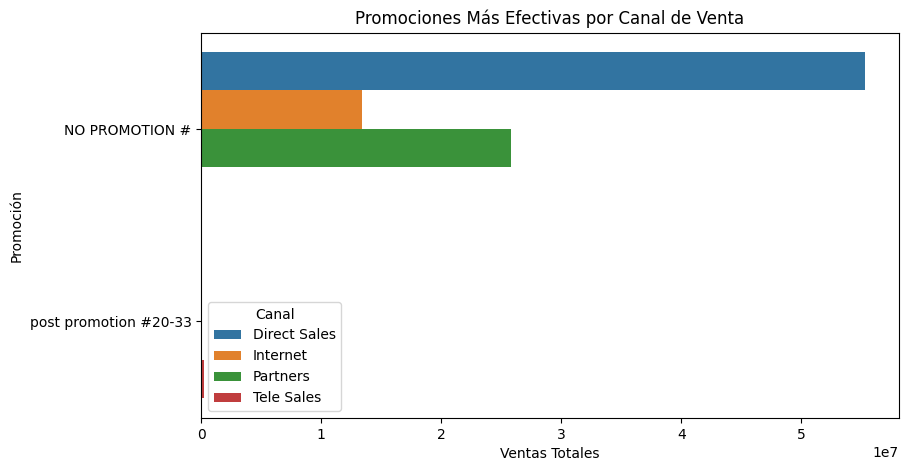

In [11]:
# -----------------------------
# 4.8 Promociones más efectivas por canal
# -----------------------------

query = """
SELECT
    ch.channel_desc AS CHANNEL,
    p.promo_name AS PROMOTION,
    SUM(s.amount_sold) AS TOTAL_SALES
FROM sh.sales s
JOIN sh.channels ch ON s.channel_id = ch.channel_id
JOIN sh.promotions p ON s.promo_id = p.promo_id
GROUP BY ch.channel_desc, p.promo_name
ORDER BY ch.channel_desc, TOTAL_SALES DESC
"""


df_promo_canal = run_query(query)


df_promo_canal


df_top_promo = (
    df_promo_canal
    .sort_values(['CHANNEL', 'TOTAL_SALES'], ascending=[True, False])
    .groupby('CHANNEL')
    .head(1)
)

plt.figure(figsize=(9,5))
sns.barplot(
    data=df_top_promo,
    x='TOTAL_SALES',
    y='PROMOTION',
    hue='CHANNEL'
)
plt.title("Promociones Más Efectivas por Canal de Venta")
plt.xlabel("Ventas Totales")
plt.ylabel("Promoción")
plt.legend(title="Canal")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


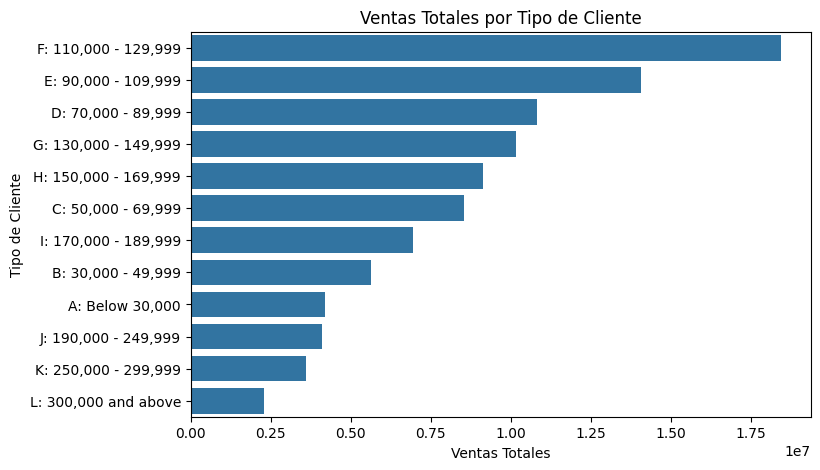

In [12]:
# -----------------------------
# 4.9 Análisis de comportamiento por tipo de cliente
# -----------------------------

query = """
SELECT
    c.cust_income_level AS CUSTOMER_TYPE,
    COUNT(DISTINCT c.cust_id) AS CUSTOMER_COUNT,
    SUM(s.amount_sold) AS TOTAL_SALES,
    AVG(s.amount_sold) AS AVG_SALE
FROM sh.sales s
JOIN sh.customers c ON s.cust_id = c.cust_id
GROUP BY c.cust_income_level
ORDER BY TOTAL_SALES DESC
"""


df_tipo_cliente = run_query(query)


df_tipo_cliente

plt.figure(figsize=(8,5))
sns.barplot(
    data=df_tipo_cliente,
    x='TOTAL_SALES',
    y='CUSTOMER_TYPE'
)
plt.title("Ventas Totales por Tipo de Cliente")
plt.xlabel("Ventas Totales")
plt.ylabel("Tipo de Cliente")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_1480\3296379769.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


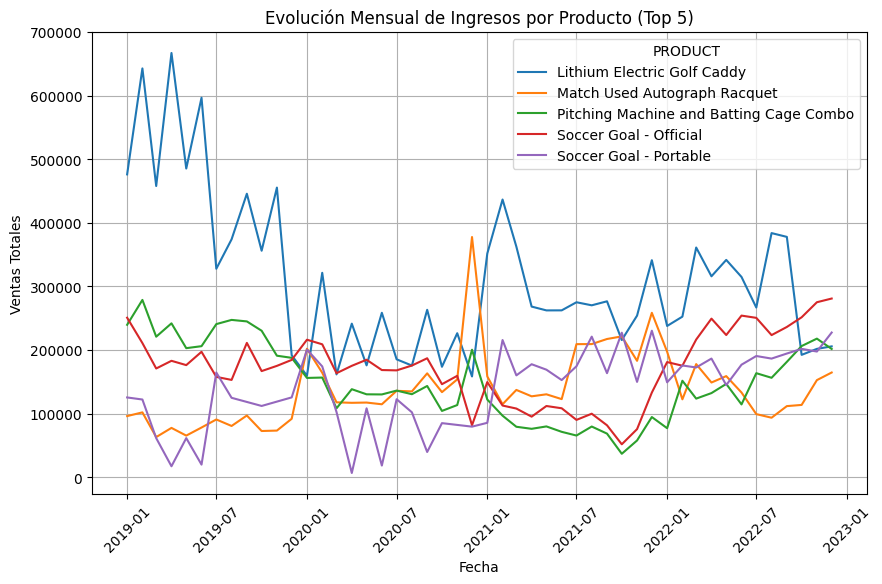

In [13]:
# -----------------------------
# 4.10 Evolución de ingresos mensuales por producto
# -----------------------------

query = """
SELECT
    p.prod_name AS PRODUCT,
    t.calendar_year AS YEAR,
    t.calendar_month_number AS MONTH,
    SUM(s.amount_sold) AS TOTAL_SALES
FROM sh.sales s
JOIN sh.products p ON s.prod_id = p.prod_id
JOIN sh.times t ON s.time_id = t.time_id
GROUP BY p.prod_name, t.calendar_year, t.calendar_month_number
ORDER BY p.prod_name, t.calendar_year, t.calendar_month_number
"""

df_evolucion = run_query(query)

df_evolucion['TOTAL_SALES'] = pd.to_numeric(
    df_evolucion['TOTAL_SALES'],
    errors='coerce'
)


df_evolucion = df_evolucion.dropna()

df_evolucion['DATE'] = pd.to_datetime(
    df_evolucion['YEAR'].astype(str) + '-' +
    df_evolucion['MONTH'].astype(str) + '-01'
)


top_products = (
    df_evolucion.groupby('PRODUCT')['TOTAL_SALES']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df_plot = df_evolucion[df_evolucion['PRODUCT'].isin(top_products)]


plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_plot,
    x='DATE',
    y='TOTAL_SALES',
    hue='PRODUCT'
)
plt.title("Evolución Mensual de Ingresos por Producto (Top 5)")
plt.xlabel("Fecha")
plt.ylabel("Ventas Totales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [14]:
# ======================================
# 5. Cierre de conexión
# ======================================

try:
    connection.close()
    print("Conexión cerrada.")
except:
    pass


Conexión cerrada.
